In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [ ]:
# ================================================
# Nama    : Apriliya Aniyatuzzuhriya
# Dataset : Social Network Ads
# Sumber  : Kaggle (https://www.kaggle.com/datasets/rakeshrau/social-network-ads)
# Jumlah data: 400 baris, 5 kolom
# Fitur   : Gender, Age, EstimatedSalary
# Target  : Purchased (0 = tidak beli, 1 = beli)
# Tujuan  : Klasifikasi apakah user akan membeli produk
#            berdasarkan usia dan gaji
# ================================================

Sumber Dataset: https://www.kaggle.com/datasets/rakeshrau/social-network-ads
Deskripsi: Dataset Social Network Ads berisi 400 baris data pelanggan dengan fitur Gender, Age, dan EstimatedSalary untuk memprediksi apakah pelanggan akan membeli produk (Purchased: 1) atau tidak (Purchased: 0). Dataset ini bersumber dari Kaggle dan umum digunakan untuk eksperimen klasifikasi biner.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
import pandas as pd

# Sesuaikan path dengan lokasi file di Drive Anda
df = pd.read_csv('/content/drive/MyDrive/Social_Network_Ads.csv')
# Kalau Excel: df = pd.read_excel('/content/drive/MyDrive/Social_Network_Ads.xlsx')

print("✅ Dataset berhasil dimuat!")
print("Shape:", df.shape)
print("\n5 baris pertama:")
df.head()

✅ Dataset berhasil dimuat!
Shape: (400, 5)

5 baris pertama:


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
# EDA
print("=== INFO DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

print("\n=== CEK MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DISTRIBUSI TARGET ===")
print(df['Purchased'].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

=== STATISTIK DESKRIPTIF ===
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    

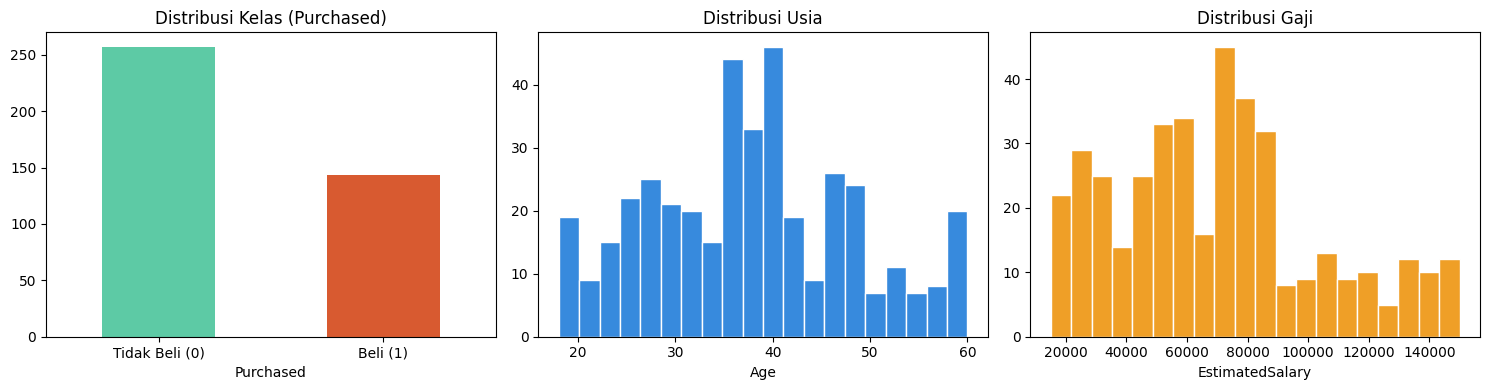

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi target
df['Purchased'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#5DCAA5','#D85A30'])
axes[0].set_title('Distribusi Kelas (Purchased)')
axes[0].set_xticklabels(['Tidak Beli (0)', 'Beli (1)'], rotation=0)

# Distribusi usia
axes[1].hist(df['Age'], bins=20, color='#378ADD', edgecolor='white')
axes[1].set_title('Distribusi Usia')
axes[1].set_xlabel('Age')

# Distribusi gaji
axes[2].hist(df['EstimatedSalary'], bins=20, color='#EF9F27', edgecolor='white')
axes[2].set_title('Distribusi Gaji')
axes[2].set_xlabel('EstimatedSalary')

plt.tight_layout()
plt.show()

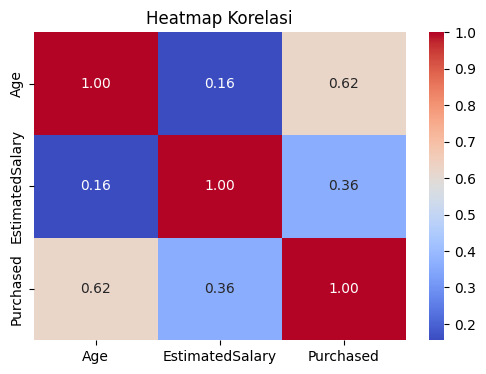

In [8]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Age', 'EstimatedSalary', 'Purchased']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:
# Hapus kolom User ID (tidak diperlukan)
df = df.drop(columns=['User ID'])

# Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Normalisasi fitur numerik (Age dan EstimatedSalary)
scaler = StandardScaler()
df[['Age', 'EstimatedSalary']] = scaler.fit_transform(df[['Age', 'EstimatedSalary']])

print("Dataset setelah preprocessing:")
print(df.head())
print(f"\nShape dataset: {df.shape}")
print("\n✅ Preprocessing selesai!")

Dataset setelah preprocessing:
   Gender       Age  EstimatedSalary  Purchased
0       1 -1.781797        -1.490046          0
1       1 -0.253587        -1.460681          0
2       0 -1.113206        -0.785290          0
3       0 -1.017692        -0.374182          0
4       1 -1.781797         0.183751          0

Shape dataset: (400, 4)

✅ Preprocessing selesai!


In [10]:
# Simpan dataset hasil preprocessing ke CSV
df_preprocessed = df.copy()
df_preprocessed.to_csv('/content/drive/MyDrive/Social_Network_Ads_preprocessed.csv', index=False)
print("✅ Dataset hasil preprocessing berhasil disimpan!")
print(f"Shape: {df_preprocessed.shape}")
df_preprocessed.head()

✅ Dataset hasil preprocessing berhasil disimpan!
Shape: (400, 4)


,Gender,Age,EstimatedSalary,Purchased
0,1,-1.781797,-1.490046,0
1,1,-0.253587,-1.460681,0
2,0,-1.113206,-0.785290,0
3,0,-1.017692,-0.374182,0
4,1,-1.781797,0.183751,0
